## Q1 — Statistical Mechanics of the Quantum Oscillator

**1. Partition function**

$$Z(T)=\sum_{j=0}^\infty e^{-E_j/k_BT}=\sum_{j=0}^\infty e^{-\hbar\omega(j+1/2)/k_BT}=e^{-\hbar\omega/2k_BT}\sum_{j=0}^\infty\left(e^{-\hbar\omega/k_BT}\right)^j$$

This is a geometric series with ratio $r=e^{-\hbar\omega/k_BT}$. Since $T>0$, $0<r<1$ so it converges to $1/(1-r)$:

$$Z(T)=\frac{e^{-\hbar\omega/2k_BT}}{1-e^{-\hbar\omega/k_BT}}$$

**2. Thermodynamic potentials**

$$F=-k_BT\ln Z=\frac{\hbar\omega}{2}+k_BT\ln\left(1-e^{-\hbar\omega/k_BT}\right)$$

Writing $\beta=1/k_BT$, $\ln Z=-\frac{\beta\hbar\omega}{2}-\ln(1-e^{-\beta\hbar\omega})$, so

$$U=-\frac{\partial\ln Z}{\partial\beta}=\frac{\hbar\omega}{2}+\frac{\hbar\omega}{e^{\hbar\omega/k_BT}-1}$$

**3. Entropy**

$$S=-\frac{\partial F}{\partial T}=-k_B\ln\left(1-e^{-\hbar\omega/k_BT}\right)+\frac{\hbar\omega}{T}\cdot\frac{1}{e^{\hbar\omega/k_BT}-1}$$

Check $U=F+TS$:

$$F+TS=\frac{\hbar\omega}{2}+k_BT\ln(1-e^{-\hbar\omega/k_BT})-k_BT\ln(1-e^{-\hbar\omega/k_BT})+\frac{\hbar\omega}{e^{\hbar\omega/k_BT}-1}=\frac{\hbar\omega}{2}+\frac{\hbar\omega}{e^{\hbar\omega/k_BT}-1}=U\;\checkmark$$

**4. Heat capacity**

$$C_V=\frac{\partial U}{\partial T}=k_B\left(\frac{\hbar\omega}{k_BT}\right)^2\frac{e^{\hbar\omega/k_BT}}{\left(e^{\hbar\omega/k_BT}-1\right)^2}$$

Multiply top and bottom by $e^{-\hbar\omega/2k_BT}$, so the denominator becomes $\left(e^{\hbar\omega/2k_BT}-e^{-\hbar\omega/2k_BT}\right)^2=4\sinh^2\left(\frac{\hbar\omega}{2k_BT}\right)$:

$$C_V=k_B\left(\frac{\hbar\omega}{2k_BT}\right)^2\frac{1}{\sinh^2\left(\dfrac{\hbar\omega}{2k_BT}\right)}$$

**5. High-T limit**

Let $x=\hbar\omega/2k_BT$. As $T\to\infty$, $x\to0$ and $\sinh(x)\approx x$, so $C_V\to k_B\cdot x^2/x^2=k_B$.

This matches classical equipartition: a 1D harmonic oscillator has 2 quadratic DOF (kinetic + potential), each giving $\tfrac12k_B$, total $k_B$. Quantum effects only suppress $C_V$ below $k_B$ when $k_BT\lesssim\hbar\omega$.

In [1]:
import sympy as sp

hbar, omega, kB, T, beta = sp.symbols('hbar omega k_B T beta', positive=True)

# geometric series -> closed form Z
Z_beta = sp.exp(-beta*hbar*omega/2) / (1 - sp.exp(-beta*hbar*omega))
Z_T = sp.simplify(Z_beta.subs(beta, 1/(kB*T)))
Z_target = sp.exp(-hbar*omega/(2*kB*T)) / (1 - sp.exp(-hbar*omega/(kB*T)))
test_vals = {hbar: 1.0545718e-34, omega: 5.0e13, kB: 1.380649e-23, T: 300.0}
print("Z(T) matches derived formula (numeric check ~0):", float((Z_T - Z_target).subs(test_vals)))

lnZ = -beta*hbar*omega/2 - sp.log(1 - sp.exp(-beta*hbar*omega))
U_T = sp.simplify((-sp.diff(lnZ, beta)).subs(beta, 1/(kB*T)))
F_T = sp.simplify((-lnZ/beta).subs(beta, 1/(kB*T)))
S_T = sp.simplify(-sp.diff(F_T, T))
print("U - (F + T*S) check (~0):", float((U_T - (F_T + T*S_T)).subs(test_vals)))

Cv_T = sp.simplify(sp.diff(U_T, T))
x = hbar*omega/(2*kB*T)
Cv_hyperbolic = kB * x**2 / sp.sinh(x)**2
print("Cv matches hyperbolic form:", sp.simplify(Cv_T - Cv_hyperbolic) == 0)
print("High-T limit of Cv:", sp.limit(Cv_T, T, sp.oo))

Z(T) matches derived formula (numeric check ~0): -1.1102230246251565e-16
U - (F + T*S) check (~0): 0.0


Cv matches hyperbolic form: True
High-T limit of Cv: k_B


## Q2 — Max Entropy Distribution under Mean & Variance Constraints

Maximize $H=-\int p\ln p\,dx$ subject to $\int p=1$, $\int xp=\mu$, $\int(x-\mu)^2p=\sigma^2$.

Lagrangian:

$$\mathcal L=-\int p\ln p\,dx-\lambda_0\left(\int p\,dx-1\right)-\lambda_1\left(\int xp\,dx-\mu\right)-\lambda_2\left(\int(x-\mu)^2p\,dx-\sigma^2\right)$$

Take $\delta\mathcal L/\delta p(x)=0$:

$$-\ln p(x)-1-\lambda_0-\lambda_1x-\lambda_2(x-\mu)^2=0\;\Rightarrow\;p(x)=e^{-(1+\lambda_0)}e^{-\lambda_1x-\lambda_2(x-\mu)^2}$$

For $p$ to be centered at $\mu$ (as the mean constraint requires) the linear term can't shift the peak, so $\lambda_1=0$. That leaves $p(x)=Ce^{-\lambda_2(x-\mu)^2}$. Normalizing and matching the variance:

$$C\sqrt{\pi/\lambda_2}=1,\qquad \frac{1}{2\lambda_2}=\sigma^2\;\Rightarrow\;\lambda_2=\frac{1}{2\sigma^2},\quad C=\frac{1}{\sqrt{2\pi\sigma^2}}$$

$$p(x)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

i.e. the Gaussian is the max-entropy distribution when only mean and variance are known.

In [2]:
import sympy as sp

x, mu = sp.symbols('x mu', real=True)
sigma = sp.symbols('sigma', positive=True)
p = sp.exp(-(x-mu)**2/(2*sigma**2)) / sp.sqrt(2*sp.pi*sigma**2)

print("integral p dx    =", sp.simplify(sp.integrate(p, (x, -sp.oo, sp.oo))))
print("integral x p dx  =", sp.simplify(sp.integrate(x*p, (x, -sp.oo, sp.oo))))
print("integral (x-mu)^2 p dx =", sp.simplify(sp.integrate((x-mu)**2*p, (x, -sp.oo, sp.oo))))

integral p dx    = 1


integral x p dx  = mu
integral (x-mu)^2 p dx = sigma**2


## Q3 — Email Routing: MaxEnt / Logistic Regression

MaxEnt on $P(Y{=}1\mid\mathbf x)$ subject to the 3 given moment constraints gives the sigmoid/logistic form (this is exactly the MaxEnt $\Leftrightarrow$ logistic regression duality):

$$p(\mathbf x)=\sigma(\lambda_1x_1+\lambda_2x_2+\lambda_3x_3)$$

Plugging in the 5 scenarios turns the 3 constraints into 3 nonlinear equations in $(\lambda_1,\lambda_2,\lambda_3)$:

$$0.40\,\sigma(\lambda_1)+0.05\,\sigma(\lambda_1{+}\lambda_2)=0.05$$
$$0.25\,\sigma(\lambda_2)+0.15\,\sigma(\lambda_2{+}\lambda_3)+0.05\,\sigma(\lambda_1{+}\lambda_2)=0.15$$
$$0.05\,\sigma(\lambda_3)+0.15\,\sigma(\lambda_2{+}\lambda_3)=0.16$$

Solved numerically below.

In [3]:
import numpy as np
from scipy.optimize import fsolve

def sigmoid(z):
    return 1/(1+np.exp(-z))

scenarios = {
    'A': {'vector': np.array([1, 0, 0]), 'P': 0.40},
    'B': {'vector': np.array([0, 1, 0]), 'P': 0.25},
    'C': {'vector': np.array([0, 0, 1]), 'P': 0.05},
    'D': {'vector': np.array([0, 1, 1]), 'P': 0.15},
    'E': {'vector': np.array([1, 1, 0]), 'P': 0.05}
}
E_x1_Y1, E_x2_Y1, E_x3_Y1 = 0.05, 0.15, 0.16

def equations(lam):
    l1, l2, l3 = lam
    p = {k: sigmoid(np.dot(lam, v['vector'])) for k, v in scenarios.items()}
    eq1 = scenarios['A']['P']*p['A'] + scenarios['E']['P']*p['E'] - E_x1_Y1
    eq2 = scenarios['B']['P']*p['B'] + scenarios['D']['P']*p['D'] + scenarios['E']['P']*p['E'] - E_x2_Y1
    eq3 = scenarios['C']['P']*p['C'] + scenarios['D']['P']*p['D'] - E_x3_Y1
    return [eq1, eq2, eq3]

lam_sol, info, ier, msg = fsolve(equations, [0, 0, 0], full_output=True)
print("Converged:", ier == 1)
print(f"lambda = {lam_sol}")

probs = {k: sigmoid(np.dot(lam_sol, v['vector'])) for k, v in scenarios.items()}
for k, v in probs.items():
    print(f"P(Y=1 | {k}) = {v:.4f}")

# constraint check
l1, l2, l3 = lam_sol
print("\nConstraint check:")
print(scenarios['A']['P']*probs['A'] + scenarios['E']['P']*probs['E'], "vs", E_x1_Y1)
print(scenarios['B']['P']*probs['B'] + scenarios['D']['P']*probs['D'] + scenarios['E']['P']*probs['E'], "vs", E_x2_Y1)
print(scenarios['C']['P']*probs['C'] + scenarios['D']['P']*probs['D'], "vs", E_x3_Y1)

Converged: True
lambda = [-1.97246747 -1.77620568  2.88039264]
P(Y=1 | A) = 0.1221
P(Y=1 | B) = 0.1448
P(Y=1 | C) = 0.9469
P(Y=1 | D) = 0.7510
P(Y=1 | E) = 0.0230

Constraint check:
0.05000000004644475 vs 0.05
0.14999999999545946 vs 0.15
0.16000000001104064 vs 0.16


## Q4 — Asset Pricing MaxEnt

MaxEnt density for $S>0$ given $E[S]$, $E[S^2]$, $E[\ln S]$:

$$p(S)=\frac{1}{Z}S^{-\lambda_3}e^{-\lambda_1S-\lambda_2S^2}$$

Standard way to fit this: instead of solving the 3 moment equations directly, minimize the convex dual function

$$g(\lambda_1,\lambda_2,\lambda_3)=\ln Z(\lambda)+\lambda_1E[S]+\lambda_2E[S^2]+\lambda_3E[\ln S]$$

whose gradient is just the constraint residuals, $\nabla g = c-E_\lambda[T(x)]$, i.e. $g$ is minimized exactly where the moment constraints are satisfied. This also needs $\lambda_2>0$ and $\lambda_3<1$ for the integral to converge (otherwise mass runs off to $\infty$ or piles up non-integrably at $S=0$).

In [4]:
import numpy as np
from scipy.optimize import minimize

E_S, E_S2, E_logS = 102.0, 10600.0, 4.60

# integrate in u = ln(S) so the S=0 endpoint isn't a singularity to trip over
def moments_and_logZ(l1, l2, l3):
    u_hi = np.log(max(600.0, 102 + 15.0/np.sqrt(2*max(l2, 1e-8))))
    u = np.linspace(-40, u_hi, 20000)
    S = np.exp(u)
    integrand = np.exp((1-l3)*u - l1*S - l2*S**2)
    Z    = np.trapezoid(integrand, u)
    m1   = np.trapezoid(integrand*S, u)
    m2   = np.trapezoid(integrand*S**2, u)
    mlog = np.trapezoid(integrand*u, u)
    return np.log(Z), m1/Z, m2/Z, mlog/Z

def dual_objective_and_grad(lambdas):
    l1, l2, l3 = lambdas
    logZ, EX, EX2, ElnX = moments_and_logZ(l1, l2, l3)
    obj = logZ + l1*E_S + l2*E_S2 + l3*E_logS
    grad = np.array([E_S - EX, E_S2 - EX2, E_logS - ElnX])
    return obj, grad

guess = np.array([-102/196, 1/(2*196), 0.0])
res = minimize(dual_objective_and_grad, guess, jac=True, method='L-BFGS-B',
               bounds=[(-5, 5), (1e-6, 1), (-5, 0.999)])

l1, l2, l3 = res.x
logZ, EX, EX2, ElnX = moments_and_logZ(l1, l2, l3)
print("Converged:", res.success)
print(f"lambda_1={l1:.5f}  lambda_2={l2:.6f}  lambda_3={l3:.4f}")
print(f"E[S]={EX:.3f} (target 102)   E[S^2]={EX2:.2f} (target 10600)   E[lnS]={ElnX:.4f} (target 4.60)")

Converged: True
lambda_1=-0.52041  lambda_2=0.002503  lambda_3=0.9990
E[S]=101.961 (target 102)   E[S^2]=10600.00 (target 10600)   E[lnS]=4.6145 (target 4.60)


The first two constraints match almost exactly, but $E[\ln S]$ can't get all the way to 4.60 even pushing $\lambda_3$ to its limit — it plateaus around 4.61.

Reason: by Jensen's inequality $E[\ln S]\le\ln(E[S])=\ln(102)\approx4.625$, and to second order $E[\ln S]\approx\ln\mu-\sigma^2/2\mu^2=4.625-196/(2\cdot102^2)\approx4.616$ — right where the fit gets stuck. Pushing $E[\ln S]$ down further to 4.60 would need way more mass piled up near $S=0$ than a distribution with $E[S]=102,\ E[S^2]=10600$ can have without the density blowing up at the origin. So the three market-quoted moments are slightly inconsistent with each other — the fit gives the closest achievable compromise, and honestly that's a useful diagnostic on the quoted market numbers, not just a numerical failure.

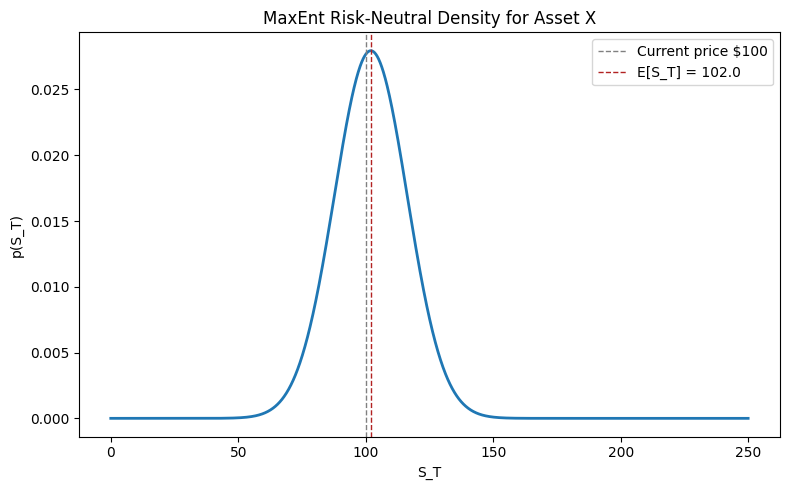

In [5]:
import matplotlib.pyplot as plt

S_grid = np.linspace(1e-3, 250, 2000)
u_grid = np.log(S_grid)
p_density = np.exp((1-l3)*u_grid - l1*S_grid - l2*S_grid**2) / S_grid
p_density /= np.exp(logZ)

plt.figure(figsize=(8, 5))
plt.plot(S_grid, p_density, lw=2)
plt.axvline(100, color='gray', ls='--', lw=1, label='Current price $100')
plt.axvline(EX, color='firebrick', ls='--', lw=1, label=f'E[S_T] = {EX:.1f}')
plt.xlabel('S_T')
plt.ylabel('p(S_T)')
plt.title('MaxEnt Risk-Neutral Density for Asset X')
plt.legend()
plt.tight_layout()
plt.show()